In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
#nltk.download('wordnet')
#nltk.download('stopwords')


In [2]:
#pull the dataset 
df=pd.read_csv('./restaurant-reviews/Restaurant_Reviews.tsv', sep='\t', index_col=False)

#Check if there is any missing data
df.isnull().sum()

Review    0
Liked     0
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


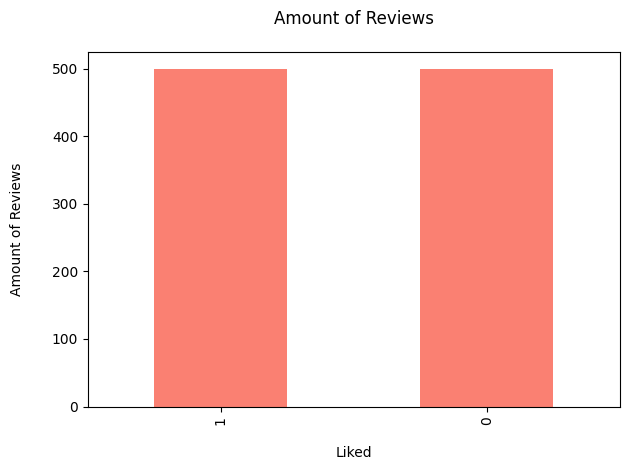

In [4]:
#Create a bar graph for Liked column
liked=df["Liked"].value_counts().plot(kind = "bar", color = "salmon")
plt.title("Amount of Reviews", pad = 20)
plt.xlabel("Liked", labelpad = 15)
plt.ylabel("Amount of Reviews",labelpad = 20)
plt.tight_layout()
plt.savefig('images/l_of_reviews.png')
plt.show()

In [5]:
#Function to remove Punctuation
def remove_punct(text):
    text_nopunct = "".join([char for char in text if char not in string.punctuation])# It will discard all punctuations
    return text_nopunct
df['Review_cleaned']  = df['Review'].apply(lambda x: remove_punct(x))

In [6]:
df.head()

,Review,Liked,Review_cleaned
0,Wow... Loved this place.,1,Wow Loved this place
1,Crust is not good.,0,Crust is not good
2,Not tasty and the texture was just nasty.,0,Not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...,1,The selection on the menu was great and so wer...


In [7]:
# Function to Tokenize words
def tokenize(text):
    tokens = re.split('\W+', text) #W+ means that either a word character (A-Za-z0-9_) or a dash (-) can go there.
    return tokens
#We convert to lower as Python is case-sensitive. 
df['Review_cleaned']  = df['Review_cleaned'] .apply(lambda x: tokenize(x.lower())) 

<>:3: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\W'
/var/folders/dv/x_yhvm8x1vj_7019b6vm83pr0000gn/T/ipykernel_54145/1969953128.py:3: SyntaxWarning: invalid escape sequence '\W'
  tokens = re.split('\W+', text) #W+ means that either a word character (A-Za-z0-9_) or a dash (-) can go there.


In [8]:
stopword = nltk.corpus.stopwords.words('english')


In [9]:
# Function to remove Stopwords
# All English Stopwords
stopword = nltk.corpus.stopwords.words('english')

def remove_stopwords(tokenized_list):
    text = [word for word in tokenized_list if word not in stopword]# To remove all stopwords
    return text
df['Review_cleaned'] = df['Review_cleaned'] .apply(lambda x: remove_stopwords(x))

In [10]:
df.head()

,Review,Liked,Review_cleaned
0,Wow... Loved this place.,1,"[wow, loved, place]"
1,Crust is not good.,0,"[crust, good]"
2,Not tasty and the texture was just nasty.,0,"[tasty, texture, nasty]"
3,Stopped by during the late May bank holiday of...,1,"[stopped, late, may, bank, holiday, rick, stev..."
4,The selection on the menu was great and so wer...,1,"[selection, menu, great, prices]"


In [11]:
#Lemmatizer
wn = nltk.WordNetLemmatizer()

def lemmatizing(tokenized_text):
    text = [wn.lemmatize(word) for word in tokenized_text]
    return text
df['Review_cleaned']  = df['Review_cleaned'] .apply(lambda x: lemmatizing(x))

#Save the cleaned dataset
df.to_csv('rest_review_data_cleaned.csv', index=False)